Apply LDA for dimensionality reduction and any classifier for face recognition on the ORL dataset and analyze the performance.

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import shutil
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC


dataset_path = "../datasets/ORL_dataset"

In [122]:
classes = os.listdir(dataset_path)

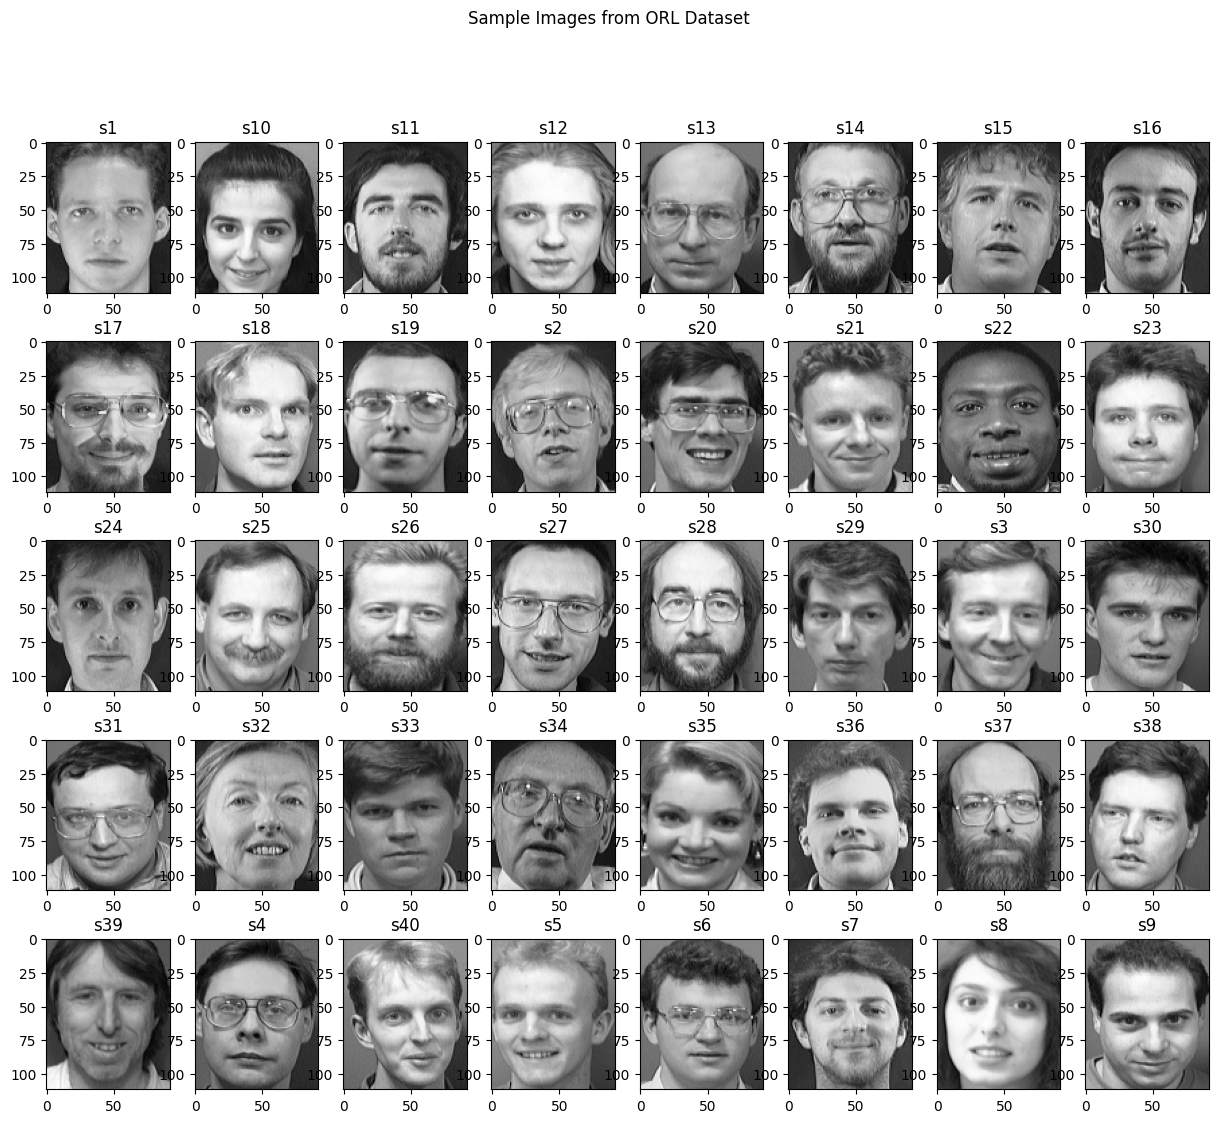

In [ ]:
plt.subplots(5, 8, figsize=(15, 12.5))
plt.suptitle("Sample Images from ORL Dataset", fontsize=12)
for class_name in classes:
    image = cv2.imread(os.path.join(dataset_path, class_name, "1.pgm"), cv2.IMREAD_GRAYSCALE)
    plt.subplot(5, 8, classes.index(class_name) + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"{class_name}")

In [6]:
test_ratio = 0.2

classes = os.listdir(dataset_path)

for class_name in classes:

    os.makedirs(f"../datasets/train/{class_name}", exist_ok=True)
    os.makedirs(f"../datasets/test/{class_name}", exist_ok=True)

    images = os.listdir(f"../datasets/ORL_dataset/{class_name}")
    train_images, test_images = train_test_split(images, test_size=test_ratio, random_state=42)

    for img in train_images:
        shutil.copy(f"../datasets/ORL_dataset/{class_name}/{img}", f"../datasets/train/{class_name}/{img}")
    print(f"Copied images for {class_name} to train folder")

    for img in test_images:
        shutil.copy(f"../datasets/ORL_dataset/{class_name}/{img}", f"../datasets/test/{class_name}/{img}")
    print(f"Copied images for {class_name} to test folder")


    

Copied images for s1 to train folder
Copied images for s1 to test folder
Copied images for s10 to train folder
Copied images for s10 to test folder
Copied images for s11 to train folder
Copied images for s11 to test folder
Copied images for s12 to train folder
Copied images for s12 to test folder
Copied images for s13 to train folder
Copied images for s13 to test folder
Copied images for s14 to train folder
Copied images for s14 to test folder
Copied images for s15 to train folder
Copied images for s15 to test folder
Copied images for s16 to train folder
Copied images for s16 to test folder
Copied images for s17 to train folder
Copied images for s17 to test folder
Copied images for s18 to train folder
Copied images for s18 to test folder
Copied images for s19 to train folder
Copied images for s19 to test folder
Copied images for s2 to train folder
Copied images for s2 to test folder
Copied images for s20 to train folder
Copied images for s20 to test folder
Copied images for s21 to trai

In [32]:
train_set = "../datasets/train"
test_set = "../datasets/test"

In [123]:
images_X = []
labels_y = []
for class_name in classes:
    class_path = os.path.join(train_set, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        images_X.append(image.flatten())
        labels_y.append(classes.index(class_name))
print(f"Number of images in train set: {len(images_X)}")

Number of images in train set: 320


In [58]:
labels_y = np.array(labels_y)
images_X = pd.DataFrame(images_X)

In [128]:
lda = LDA(n_components=39)


In [129]:
images_X_lda = lda.fit_transform(images_X, labels_y)


In [130]:
images_X_lda_df = pd.DataFrame(images_X_lda)

In [131]:
images_X_lda_df

,0,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,35,36,37,38
0,-4.195820,1.440183,-9.526318,0.985577,-2.238878,2.710791,-3.748485,-2.019688,0.134558,3.244815,...,-0.146298,-0.010709,-0.762054,-1.603679,-1.450909,-0.717439,-0.158892,1.904321,-0.417238,0.202857
1,-5.915632,3.863930,-9.567232,7.083888,-2.749441,1.659635,-1.617893,0.196132,-3.446693,2.177965,...,-0.934556,-0.862796,1.249658,2.794213,-0.604517,0.144966,-1.761977,1.138139,-1.043206,-2.155021
2,-7.663957,1.713726,-10.372344,0.992018,-2.778074,-3.278244,-0.597992,0.730577,-0.502767,2.438865,...,-0.771264,-0.053586,-0.718594,0.994174,1.035052,0.030680,-2.419612,0.035202,2.448436,0.102956
3,-7.147968,-0.097785,-9.072887,4.785691,-0.299194,-0.654152,-1.655769,1.404543,-0.908319,4.447840,...,1.408527,0.096570,1.138816,1.260218,-1.183134,0.454599,-2.101472,0.518102,-0.521245,-0.236318
4,-7.168803,0.240219,-8.515570,2.347091,0.333050,1.075298,0.154636,1.959033,-0.608113,4.345680,...,0.538302,1.066564,0.165476,1.916962,0.106944,-0.846340,-1.257969,0.971374,0.499374,0.184096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,-0.170546,0.317235,6.252161,2.901864,-2.681779,1.557313,-0.881094,-3.414175,4.079278,0.662487,...,-0.219404,0.386893,0.199659,0.136986,-1.332430,-0.904999,1.379555,1.063660,-0.688705,-0.289642
316,0.060807,2.557154,5.252318,2.988304,-2.362040,0.248275,0.788925,-7.416892,2.354512,2.145689,...,-0.030777,0.476900,-0.445431,0.168788,1.588798,-0.760137,0.041938,-2.940723,-0.561291,-0.915768
317,-1.398813,1.105114,7.809580,-0.047862,-3.745474,1.667271,-0.299620,-8.218174,1.227088,1.422216,...,-0.223651,0.550969,0.188937,-1.548236,0.209080,1.840205,-1.056945,0.294249,0.861716,-2.366692
318,-2.143815,1.692445,7.472940,1.946441,-2.147201,1.074111,0.807094,-3.373334,1.865819,1.020588,...,-2.101607,1.308368,0.081416,-0.980464,-1.099119,-0.399265,-1.529202,-0.458902,0.489447,1.301076


In [2]:
explained_variance = lda.explained_variance_ratio_
print(f"Explained variance by LDA components: {explained_variance}")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=images_X_lda_df[:, 0], y=images_X_lda_df[:, 1], hue=labels_y, palette="Set2")
plt.title("LDA of Iris Dataset")
plt.xlabel("Component 1")
plt.ylabel("Component 2")


NameError: name 'lda' is not defined

In [134]:
test_images_X = []
test_labels_y = []
for class_name in classes:
    class_path = os.path.join(test_set, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        test_images_X.append(image.flatten())
        test_labels_y.append(classes.index(class_name))

In [135]:
test_images_X_df = pd.DataFrame(test_images_X)
test_labels_y = np.array(test_labels_y)

In [136]:
test_images_X_lda = lda.transform(test_images_X_df)
test_images_X_lda_df = pd.DataFrame(test_images_X_lda)


Training SVM with LDA applied on the features

In [179]:
svm_01 = SVC(kernel="linear", gamma="scale")
svm_01.fit(images_X_lda, labels_y)

SVC(kernel='linear')

In [167]:
y_pred = svm_01.predict(test_images_X_lda)

In [168]:
cl_report = classification_report(test_labels_y, y_pred, target_names=classes)
print(cl_report)

              precision    recall  f1-score   support

          s1       1.00      0.50      0.67         2
         s10       1.00      1.00      1.00         2
         s11       1.00      1.00      1.00         2
         s12       1.00      1.00      1.00         2
         s13       1.00      1.00      1.00         2
         s14       1.00      1.00      1.00         2
         s15       1.00      1.00      1.00         2
         s16       0.67      1.00      0.80         2
         s17       1.00      1.00      1.00         2
         s18       1.00      1.00      1.00         2
         s19       1.00      1.00      1.00         2
          s2       1.00      1.00      1.00         2
         s20       1.00      1.00      1.00         2
         s21       1.00      1.00      1.00         2
         s22       1.00      1.00      1.00         2
         s23       1.00      1.00      1.00         2
         s24       1.00      1.00      1.00         2
         s25       1.00    

In [164]:
ac_score = accuracy_score(test_labels_y, y_pred)
print(f"Accuracy of the SVM model on test set: {ac_score}")


Accuracy of the SVM model on test set: 0.9625


Text(0.5, 1.0, 'Confusion Matrix for SVM Model')

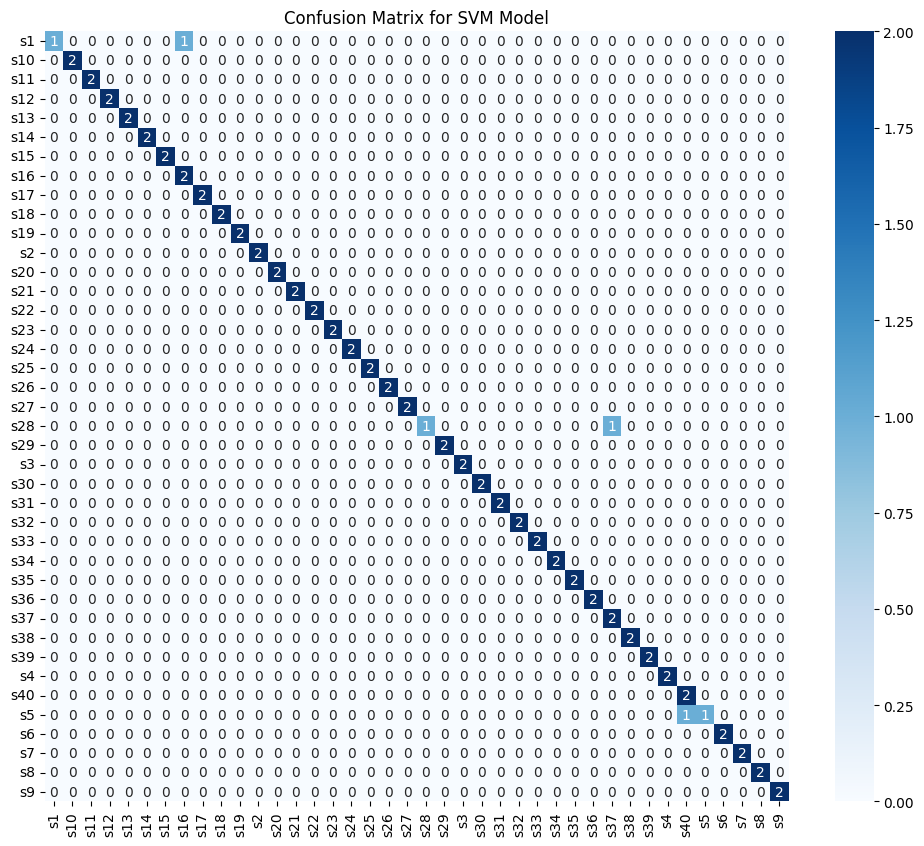

In [178]:
cf = confusion_matrix(test_labels_y, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cf, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix for SVM Model")

Training SVM with original features

In [ ]:
svm_02 = SVC(kernel="linear", gamma="scale")
svm_02.fit(images_X, labels_y)

CPU times: total: 0 ns
Wall time: 0 ns


In [170]:
y_pred_02 = svm_02.predict(test_images_X_df)
cl_report_02 = classification_report(test_labels_y, y_pred_02, target_names=classes)
print(cl_report_02)

              precision    recall  f1-score   support

          s1       1.00      1.00      1.00         2
         s10       1.00      0.50      0.67         2
         s11       1.00      1.00      1.00         2
         s12       1.00      1.00      1.00         2
         s13       1.00      1.00      1.00         2
         s14       1.00      1.00      1.00         2
         s15       1.00      1.00      1.00         2
         s16       1.00      1.00      1.00         2
         s17       1.00      1.00      1.00         2
         s18       0.67      1.00      0.80         2
         s19       1.00      1.00      1.00         2
          s2       1.00      1.00      1.00         2
         s20       1.00      1.00      1.00         2
         s21       1.00      1.00      1.00         2
         s22       1.00      1.00      1.00         2
         s23       1.00      1.00      1.00         2
         s24       1.00      1.00      1.00         2
         s25       1.00    

In [171]:
ac_score_02 = accuracy_score(test_labels_y, y_pred_02)
print(f"Accuracy of the SVM model on test set without LDA: {ac_score_02}")

Accuracy of the SVM model on test set without LDA: 0.9625


Text(0.5, 1.0, 'Confusion Matrix for SVM Model without LDA')

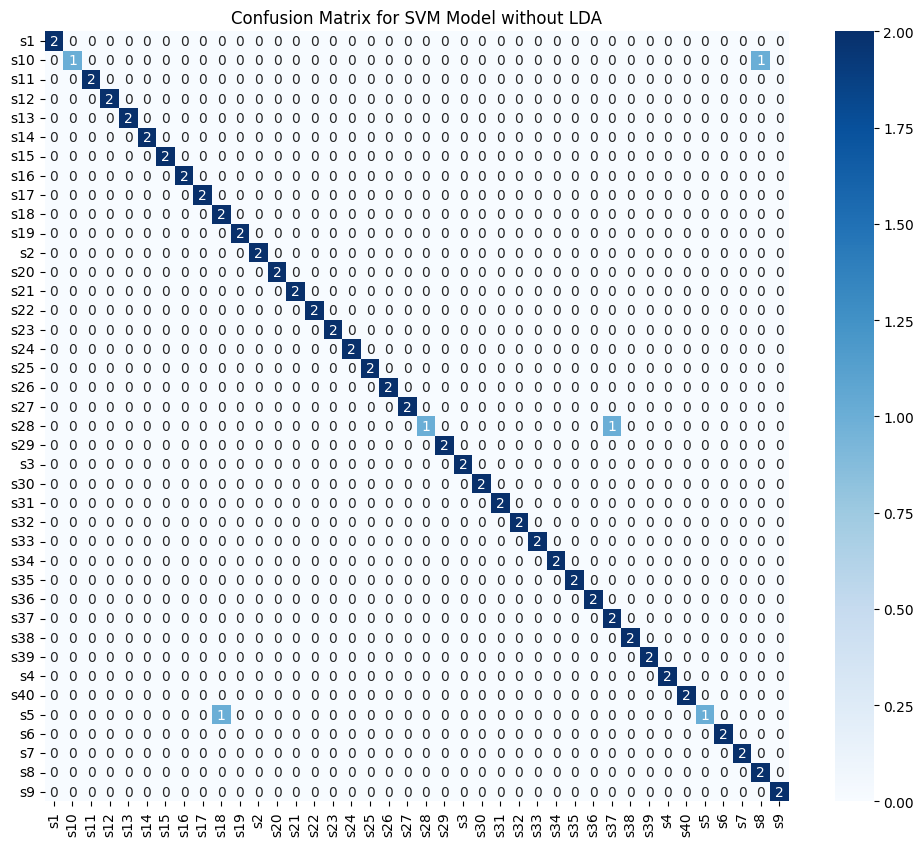

In [175]:
cf_02 = confusion_matrix(test_labels_y, y_pred_02)
plt.figure(figsize=(12, 10))
sns.heatmap(cf_02, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix for SVM Model without LDA")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/hrishikesh/scikit_learn_data
Dataset shape: (400, 4096), Labels shape: (400,)
LDA-transformed shape: (280, 39)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         3
           9       1.00      0.67      0.80         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         3
          13       1

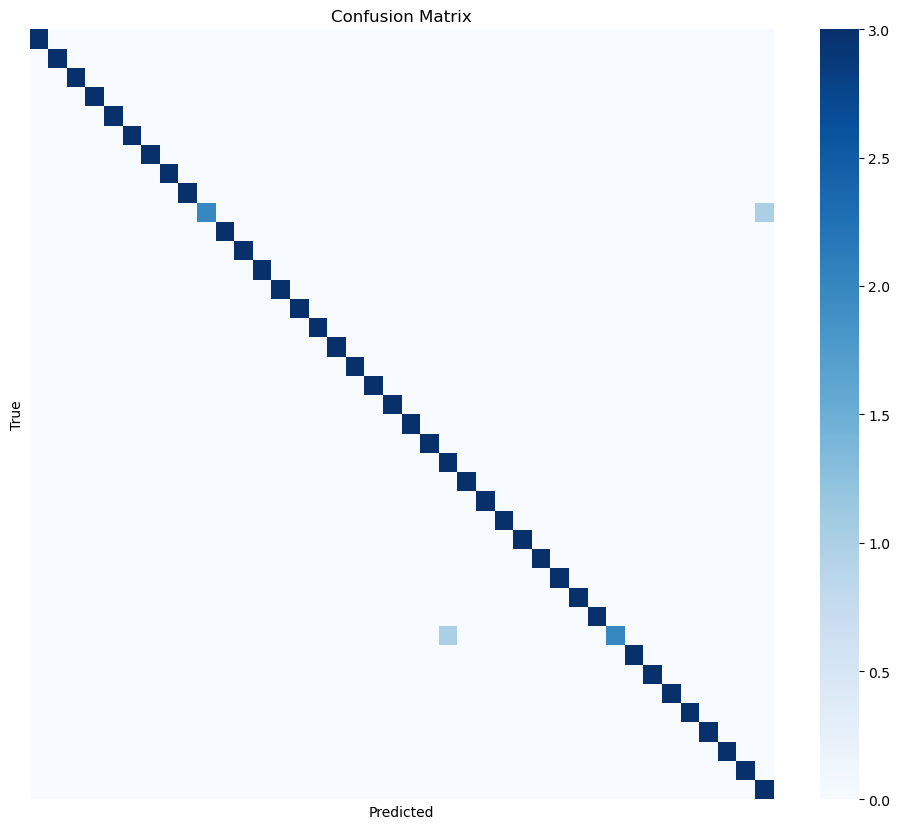

In [1]:
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the ORL Dataset
data = fetch_olivetti_faces()
X = data.data  # 400 samples, 4096 features (64x64 images)
y = data.target  # 40 classes (subjects)

print(f"Dataset shape: {X.shape}, Labels shape: {y.shape}")

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 3: Standardize features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Step 4: Apply LDA
lda = LinearDiscriminantAnalysis(n_components=39)  # max components = n_classes - 1
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_test_lda = lda.transform(X_test_std)

print(f"LDA-transformed shape: {X_train_lda.shape}")

# Step 5: Train Classifier (SVM)
classifier = SVC(kernel='linear', C=1, random_state=42)
classifier.fit(X_train_lda, y_train)

# Step 6: Predict and Analyze Performance
y_pred = classifier.predict(X_test_lda)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Step 7: Plot Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, annot=False, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()